# NSCH Data Analysis

**Dataset:** National Survey of Children’s Health (NSCH)  
**Year:** 2024  
**Source:** U.S. Census Bureau / HRSA Maternal and Child Health Bureau  

## Research Role

The NSCH serves as the primary child- and family-level dataset for this project. This analysis examines factors associated with pediatric mental health need and unmet mental health care, with particular attention to factors that may be relevant to service or digital intervention.

## Research Questions

1. What factors are associated with unmet pediatric mental health care among children who need care?
2. Which child, family, and access-related factors appear most strongly associated with unmet need?
3. Which of these factors may be modifiable or addressable through service or digital intervention?

## Analysis Approach

This notebook applies the statistical concepts used in the Extern exploratory data analysis framework, including:

- descriptive statistics
- probability and prevalence estimates
- group comparisons
- hypothesis testing
- correlation where appropriate
- regression where appropriate
- Python-generated visualizations
- interpretation of findings in relation to the research questions

## Load the Cleaned NSCH Dataset

This analysis uses the cleaned NSCH dataset created during the data preparation phase. The cleaned file contains the variables selected for the pediatric mental health research questions and will serve as the analysis-ready source for this notebook.

Before beginning the statistical analysis, the dataset is loaded and its dimensions are confirmed.

In [4]:
import pandas as pd
from pathlib import Path

# Define path to cleaned NSCH dataset
data_path = Path("../../data/cleaned/NSCH_2024_cleaned_ages_6_to_17.csv")

# Load cleaned dataset
nsch = pd.read_csv(data_path)

print("Dataset shape:", nsch.shape)
nsch.head()

Dataset shape: (37534, 107)


,household_id,sampling_stratum,final_sampling_weight,state_fips_code,metropolitan_principal_city_status,hrsa_region,neighborhood_support,neighborhood_safety,neighborhood_amenities_count,provider_communication_with_other_services,...,ACEdomviol_24,ACEneighviol_24,ACEmhealth_24,ACEdrug_24,ACEdiscrim_24,ACEHealthDiscrim_24,ACE6ctHH_24,ACE2more6HH_24,ACEctComm_24,ACE1moreComm_24
0,24000016,1,14108.624370,48,2,6,1,1,99,2,...,2,2,2,2,2,2,0,1,0,1
1,24000081,1,1763.619834,47,2,4,2,2,1,2,...,2,2,2,2,2,2,0,1,0,1
2,24000088,1,109.931073,31,2,7,1,1,3,2,...,2,2,2,2,2,2,0,1,0,1
3,24000089,2,948.037623,27,2,5,1,1,2,2,...,2,2,1,1,2,2,3,3,0,1
4,24000173,1,532.319837,9,2,1,1,1,3,1,...,2,2,2,2,1,2,0,1,1,2


In [5]:
# Display all cleaned NSCH column names
for i, col in enumerate(nsch.columns, start=1):
    print(f"{i}. {col}")

1. household_id
2. sampling_stratum
3. final_sampling_weight
4. state_fips_code
5. metropolitan_principal_city_status
6. hrsa_region
7. neighborhood_support
8. neighborhood_safety
9. neighborhood_amenities_count
10. provider_communication_with_other_services
11. provider_communication_rating
12. sidewalks_available
13. park_available
14. recreation_center_available
15. library_available
16. child_age_years
17. child_sex
18. child_race
19. child_hispanic_ethnicity
20. anxiety_24
21. AnxietSev_24
22. depress_24
23. DepresSev_24
24. ADHD_24
25. ADHDSev_24
26. ADHDind_24
27. ADHDSevInd_24
28. autism_24
29. AutismSev_24
30. AutismInd_24
31. behavior_24
32. BehavSev_24
33. tourette_24
34. TouretSev_24
35. DevDelay_24
36. speech_24
37. learning_24
38. IntDisab_24
39. ADHDMed_24
40. ADHDBehTreat_24
41. ASDMed_24
42. ASDBehTreat_24
43. MedEmotion_24
44. therapy_24
45. rxmeds_24
46. MentHCare_24
47. MentHDiff_24
48. mhealth_24
49. mhneeds_24
50. nomAnxietyDep12to17_24
51. MEDB10ScrQ5_24
52. povl

## Analysis Variables

This notebook analyzes the cleaned 2024 NSCH dataset for children ages 6–17.

The analysis focuses on the variables retained during the data cleaning phase that are most relevant to the research questions. These variables are organized into the following groups:

- **Mental health:** anxiety, depression, ADHD, behavioral conditions, and overall mental health need
- **Mental health care:** therapy, medication, receipt of care, and difficulty obtaining care
- **Insurance and socioeconomic factors:** insurance coverage, insurance gaps, adequacy of coverage, and poverty level
- **Adverse childhood experiences (ACEs):** total ACE exposure and individual ACE indicators
- **Family factors:** caregiver physical and mental health, family resilience, and housing instability
- **School and social factors:** school engagement, grades, missed school, bullying, school safety, and extracurricular participation
- **Neighborhood factors:** neighborhood support, safety, and amenities
- **Demographic and geographic factors:** age, sex, race/ethnicity, state, and HRSA region

The goal is to identify which factors are most strongly associated with pediatric mental health need and difficulty accessing mental health care, and which findings may be most relevant for later service or digital intervention research.

In [6]:
# Review the cleaned NSCH variables available for analysis

analysis_groups = {
    "Mental Health": [
        "anxiety_24", "AnxietSev_24",
        "depress_24", "DepresSev_24",
        "ADHD_24", "ADHDSev_24",
        "behavior_24", "BehavSev_24",
        "mhealth_24", "mhneeds_24"
    ],

    "Mental Health Care": [
        "therapy_24",
        "rxmeds_24",
        "MentHCare_24",
        "MentHDiff_24"
    ],

    "Insurance and Poverty": [
        "povlev4_24",
        "insurance_24",
        "CurrIns_24",
        "InsGap_24",
        "InsAdeq_24"
    ],

    "ACEs": [
        "ACEct_24",
        "ACE2more_24",
        "ACEincome_24",
        "ACEdivorce_24",
        "ACEdeath_24",
        "ACEjail_24",
        "ACEdomviol_24",
        "ACEneighviol_24",
        "ACEmhealth_24",
        "ACEdrug_24",
        "ACEdiscrim_24"
    ],

    "Family": [
        "FAMILY_R",
        "ParentPhH_24",
        "ParentMH_24",
        "HousingInstab_24"
    ],

    "School and Social": [
        "SchlEngage_24",
        "GRADES",
        "SchlMiss_24",
        "bullied_24",
        "SchlSafe_24",
        "AftSchAct_24"
    ],

    "Neighborhood": [
        "neighborhood_support",
        "neighborhood_safety",
        "neighborhood_amenities_count"
    ],

    "Demographics": [
        "child_age_years",
        "child_sex",
        "child_race",
        "child_hispanic_ethnicity",
        "state_fips_code",
        "hrsa_region"
    ]
}

for group, variables in analysis_groups.items():
    print(f"\n{group}")
    print("-" * len(group))
    for variable in variables:
        print(variable)


Mental Health
-------------
anxiety_24
AnxietSev_24
depress_24
DepresSev_24
ADHD_24
ADHDSev_24
behavior_24
BehavSev_24
mhealth_24
mhneeds_24

Mental Health Care
------------------
therapy_24
rxmeds_24
MentHCare_24
MentHDiff_24

Insurance and Poverty
---------------------
povlev4_24
insurance_24
CurrIns_24
InsGap_24
InsAdeq_24

ACEs
----
ACEct_24
ACE2more_24
ACEincome_24
ACEdivorce_24
ACEdeath_24
ACEjail_24
ACEdomviol_24
ACEneighviol_24
ACEmhealth_24
ACEdrug_24
ACEdiscrim_24

Family
------
FAMILY_R
ParentPhH_24
ParentMH_24
HousingInstab_24

School and Social
-----------------
SchlEngage_24
GRADES
SchlMiss_24
bullied_24
SchlSafe_24
AftSchAct_24

Neighborhood
------------
neighborhood_support
neighborhood_safety
neighborhood_amenities_count

Demographics
------------
child_age_years
child_sex
child_race
child_hispanic_ethnicity
state_fips_code
hrsa_region


## Mental Health Need

The first stage of the analysis examines the prevalence and distribution of pediatric mental health need in the cleaned NSCH dataset.

This section focuses on the mental health indicators retained during data preparation, including anxiety, depression, ADHD, behavioral conditions, and broader measures of mental health need. The goal is to understand how common these conditions and needs are among children ages 6–17 before examining differences in access to care and the factors associated with those differences.

In [8]:
# Examine the distribution of the main mental health indicators

mental_health_vars = [
    "anxiety_24",
    "depress_24",
    "ADHD_24",
    "behavior_24",
    "mhealth_24",
    "mhneeds_24"
]

for col in mental_health_vars:
    print(f"\n{col}")
    print(nsch[col].value_counts(dropna=False).sort_index())


anxiety_24
anxiety_24
1     30052
2       626
3      6450
99      406
Name: count, dtype: int64

depress_24
depress_24
1     34068
2       670
3      2537
99      259
Name: count, dtype: int64

ADHD_24
ADHD_24
1     30774
2       320
3      6068
99      372
Name: count, dtype: int64

behavior_24
behavior_24
1     33195
2       890
3      3328
99      121
Name: count, dtype: int64

mhealth_24
mhealth_24
1     6402
2    31132
Name: count, dtype: int64

mhneeds_24
mhneeds_24
1     6402
2     5614
3    25518
Name: count, dtype: int64


In [10]:
# Calculate prevalence of current mental health conditions
# Primary analysis scope: anxiety, depression, or ADHD
# Code 3 = currently has condition
# Code 99 = missing and excluded from denominator

current_conditions = {
    "Anxiety": "anxiety_24",
    "Depression": "depress_24",
    "ADHD": "ADHD_24"
}

prevalence_results = []

for label, col in current_conditions.items():
    valid = nsch[nsch[col] != 99]
    current = (valid[col] == 3).sum()
    total = len(valid)
    percent = current / total * 100

    prevalence_results.append({
        "Condition": label,
        "Current cases": current,
        "Valid responses": total,
        "Percent": round(percent, 1)
    })

prevalence_df = pd.DataFrame(prevalence_results)

prevalence_df

,Condition,Current cases,Valid responses,Percent
0,Anxiety,6450,37128,17.4
1,Depression,2537,37275,6.8
2,ADHD,6068,37162,16.3


### Initial Finding

Within the three conditions used to define the primary mental health population, current anxiety was the most commonly reported condition at 17.4%, followed by ADHD at 16.3% and depression at 6.8%.

These condition-specific prevalence estimates provide context for the primary analysis population, which includes children with current anxiety, depression, or ADHD.

In [11]:
# Compare current anxiety, depression, and ADHD by age

age_condition_results = []

for age in sorted(nsch["child_age_years"].dropna().unique()):
    age_data = nsch[nsch["child_age_years"] == age]

    for label, col in current_conditions.items():
        valid = age_data[age_data[col] != 99]

        current = (valid[col] == 3).sum()
        total = len(valid)
        percent = current / total * 100 if total > 0 else None

        age_condition_results.append({
            "Age": age,
            "Condition": label,
            "Current cases": current,
            "Valid responses": total,
            "Percent": round(percent, 1)
        })

age_condition_df = pd.DataFrame(age_condition_results)

age_condition_df

,Age,Condition,Current cases,Valid responses,Percent
0,6,Anxiety,180,2184,8.2
1,6,Depression,13,2190,0.6
2,6,ADHD,188,2179,8.6
3,7,Anxiety,239,2387,10.0
4,7,Depression,30,2396,1.3
5,7,ADHD,329,2388,13.8
6,8,Anxiety,304,2543,12.0
7,8,Depression,51,2548,2.0
8,8,ADHD,406,2545,16.0
9,9,Anxiety,369,2600,14.2


In [12]:
# Compare current anxiety, depression, and ADHD by age group

age_group_data = nsch.copy()

age_group_data["age_group"] = pd.cut(
    age_group_data["child_age_years"],
    bins=[5, 11, 17],
    labels=["Ages 6–11", "Ages 12–17"]
)

age_group_results = []

for age_group in ["Ages 6–11", "Ages 12–17"]:
    group = age_group_data[age_group_data["age_group"] == age_group]

    for label, col in current_conditions.items():
        valid = group[group[col] != 99]

        current = (valid[col] == 3).sum()
        total = len(valid)
        percent = current / total * 100

        age_group_results.append({
            "Age group": age_group,
            "Condition": label,
            "Current cases": current,
            "Valid responses": total,
            "Percent": round(percent, 1)
        })

age_group_df = pd.DataFrame(age_group_results)

age_group_df

,Age group,Condition,Current cases,Valid responses,Percent
0,Ages 6–11,Anxiety,2000,15447,12.9
1,Ages 6–11,Depression,366,15486,2.4
2,Ages 6–11,ADHD,2307,15436,14.9
3,Ages 12–17,Anxiety,4450,21681,20.5
4,Ages 12–17,Depression,2171,21789,10.0
5,Ages 12–17,ADHD,3761,21726,17.3


In [13]:
# Create combined target population:
# current anxiety OR current depression OR current ADHD

valid_condition_data = nsch[
    (nsch["anxiety_24"] != 99) &
    (nsch["depress_24"] != 99) &
    (nsch["ADHD_24"] != 99)
].copy()

valid_condition_data["current_anxiety_depression_or_adhd"] = (
    (valid_condition_data["anxiety_24"] == 3) |
    (valid_condition_data["depress_24"] == 3) |
    (valid_condition_data["ADHD_24"] == 3)
)

target_count = valid_condition_data["current_anxiety_depression_or_adhd"].sum()
target_total = len(valid_condition_data)
target_percent = target_count / target_total * 100

print(f"Children with current anxiety, depression, or ADHD: {target_count:,}")
print(f"Valid responses: {target_total:,}")
print(f"Percent of valid sample: {target_percent:.1f}%")

Children with current anxiety, depression, or ADHD: 9,727
Valid responses: 36,610
Percent of valid sample: 26.6%


In [14]:
# Count current conditions per child to examine comorbidity

valid_condition_data["current_condition_count"] = (
    (valid_condition_data["anxiety_24"] == 3).astype(int) +
    (valid_condition_data["depress_24"] == 3).astype(int) +
    (valid_condition_data["ADHD_24"] == 3).astype(int)
)

comorbidity_results = (
    valid_condition_data["current_condition_count"]
    .value_counts()
    .sort_index()
    .rename_axis("Number of current conditions")
    .reset_index(name="Children")
)

comorbidity_results["Percent"] = (
    comorbidity_results["Children"] /
    len(valid_condition_data) * 100
).round(1)

comorbidity_results

,Number of current conditions,Children,Percent
0,0,26883,73.4
1,1,5768,15.8
2,2,2879,7.9
3,3,1080,3.0


In [15]:
# Children with two or more current conditions

comorbid_count = (valid_condition_data["current_condition_count"] >= 2).sum()
comorbid_percent = comorbid_count / len(valid_condition_data) * 100

print(f"Children with 2 or more current conditions: {comorbid_count:,}")
print(f"Percent of valid sample: {comorbid_percent:.1f}%")

Children with 2 or more current conditions: 3,959
Percent of valid sample: 10.8%


In [16]:
# Examine comorbidity within the target mental health population only

target_population = valid_condition_data[
    valid_condition_data["current_condition_count"] >= 1
].copy()

target_comorbidity = (
    target_population["current_condition_count"]
    .value_counts()
    .sort_index()
    .rename_axis("Number of current conditions")
    .reset_index(name="Children")
)

target_comorbidity["Percent of mental health population"] = (
    target_comorbidity["Children"] /
    len(target_population) * 100
).round(1)

target_comorbidity

,Number of current conditions,Children,Percent of mental health population
0,1,5768,59.3
1,2,2879,29.6
2,3,1080,11.1


In [17]:
# Identify the exact condition combination for every child
# in the target mental health population

target_population["condition_combination"] = target_population.apply(
    lambda row: " + ".join([
        condition
        for condition, present in [
            ("Anxiety", row["anxiety_24"] == 3),
            ("Depression", row["depress_24"] == 3),
            ("ADHD", row["ADHD_24"] == 3)
        ]
        if present
    ]),
    axis=1
)

# Count each exact combination
combination_results = (
    target_population["condition_combination"]
    .value_counts()
    .reset_index()
)

combination_results.columns = [
    "Condition combination",
    "Children"
]

# Add number of conditions in each combination
combination_results["Number of conditions"] = (
    combination_results["Condition combination"]
    .str.count(r"\+")
    .add(1)
)

# Percent of the full mental health population
combination_results["Percent of mental health population"] = (
    combination_results["Children"] /
    len(target_population) * 100
).round(1)

# Rank from most common to least common
combination_results["Rank"] = range(
    1,
    len(combination_results) + 1
)

# Reorder columns
combination_results = combination_results[
    [
        "Rank",
        "Condition combination",
        "Number of conditions",
        "Children",
        "Percent of mental health population"
    ]
]

combination_results

,Rank,Condition combination,Number of conditions,Children,Percent of mental health population
0,1,ADHD,1,3040,31.3
1,2,Anxiety,1,2531,26.0
2,3,Anxiety + ADHD,2,1697,17.4
3,4,Anxiety + Depression + ADHD,3,1080,11.1
4,5,Anxiety + Depression,2,1064,10.9
5,6,Depression,1,197,2.0
6,7,Depression + ADHD,2,118,1.2


In [18]:
# Identify the most common single-condition and comorbid patterns

single_conditions = combination_results[
    combination_results["Number of conditions"] == 1
]

two_conditions = combination_results[
    combination_results["Number of conditions"] == 2
]

three_conditions = combination_results[
    combination_results["Number of conditions"] == 3
]

print("Most common single condition:")
print(
    single_conditions.iloc[0][
        ["Condition combination", "Children",
         "Percent of mental health population"]
    ]
)

print("\nMost common two-condition combination:")
print(
    two_conditions.iloc[0][
        ["Condition combination", "Children",
         "Percent of mental health population"]
    ]
)

print("\nThree-condition group:")
print(
    three_conditions.iloc[0][
        ["Condition combination", "Children",
         "Percent of mental health population"]
    ]
)

Most common single condition:
Condition combination                  ADHD
Children                               3040
Percent of mental health population    31.3
Name: 0, dtype: object

Most common two-condition combination:
Condition combination                  Anxiety + ADHD
Children                                         1697
Percent of mental health population              17.4
Name: 2, dtype: object

Three-condition group:
Condition combination                  Anxiety + Depression + ADHD
Children                                                      1080
Percent of mental health population                           11.1
Name: 3, dtype: object


In [19]:
# Compare exact condition combinations by age group

target_population["age_group"] = pd.cut(
    target_population["child_age_years"],
    bins=[5, 11, 17],
    labels=["Ages 6–11", "Ages 12–17"]
)

age_combination_results = (
    target_population
    .groupby(["age_group", "condition_combination"], observed=False)
    .size()
    .reset_index(name="Children")
)

# Calculate percent within each age group's mental health population
age_totals = (
    target_population
    .groupby("age_group", observed=False)
    .size()
    .rename("Age group total")
    .reset_index()
)

age_combination_results = age_combination_results.merge(
    age_totals,
    on="age_group"
)

age_combination_results["Percent within age group"] = (
    age_combination_results["Children"] /
    age_combination_results["Age group total"] * 100
).round(1)

# Rank combinations within each age group
age_combination_results["Rank within age group"] = (
    age_combination_results
    .groupby("age_group", observed=False)["Children"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

age_combination_results = age_combination_results.sort_values(
    ["age_group", "Rank within age group"]
)

age_combination_results

,age_group,condition_combination,Children,Age group total,Percent within age group,Rank within age group
0,Ages 6–11,ADHD,1320,3340,39.5,1
1,Ages 6–11,Anxiety,935,3340,28.0,2
2,Ages 6–11,Anxiety + ADHD,727,3340,21.8,3
4,Ages 6–11,Anxiety + Depression + ADHD,197,3340,5.9,4
3,Ages 6–11,Anxiety + Depression,120,3340,3.6,5
6,Ages 6–11,Depression + ADHD,21,3340,0.6,6
5,Ages 6–11,Depression,20,3340,0.6,7
7,Ages 12–17,ADHD,1720,6387,26.9,1
8,Ages 12–17,Anxiety,1596,6387,25.0,2
9,Ages 12–17,Anxiety + ADHD,970,6387,15.2,3


## Mental Health Care Access

The primary research question focuses on unmet mental health care among children with current anxiety, depression, or ADHD.

This section narrows the analysis to children in the target mental health population who needed mental health treatment or counseling. It then examines the prevalence of unmet care and whether access differs by age, diagnosis pattern, comorbidity, socioeconomic conditions, family factors, and other potential risk factors.

In [20]:
# Create the mental health care access population

# Keep children with current anxiety, depression, or ADHD
mental_health_population = target_population.copy()

# MentHCare_24:
# 1 = needed care and received it
# 2 = needed care but did not receive it
# 3 = did not need care
#
# Restrict analysis to children who needed care
care_population = mental_health_population[
    mental_health_population["MentHCare_24"].isin([1, 2])
].copy()

# Binary outcome:
# 0 = care received
# 1 = unmet care
care_population["unmet_care"] = (
    care_population["MentHCare_24"] == 2
).astype(int)

print(f"Target mental health population: {len(mental_health_population):,}")
print(f"Children who needed mental health care: {len(care_population):,}")

unmet_count = care_population["unmet_care"].sum()
unmet_percent = care_population["unmet_care"].mean() * 100

print(f"Children with unmet care: {unmet_count:,}")
print(f"Unmet-care rate: {unmet_percent:.1f}%")

Target mental health population: 9,727
Children who needed mental health care: 5,741
Children with unmet care: 694
Unmet-care rate: 12.1%


In [21]:
# Add age group

care_population["age_group"] = pd.cut(
    care_population["child_age_years"],
    bins=[5, 11, 17],
    labels=["Ages 6–11", "Ages 12–17"]
)

# Create comorbidity category

care_population["condition_burden"] = care_population[
    "current_condition_count"
].map({
    1: "One condition",
    2: "Two conditions",
    3: "Three conditions"
})

def unmet_rate_table(data, group_col):
    results = (
        data.groupby(group_col, observed=False)
        .agg(
            Children=("unmet_care", "size"),
            Unmet_care=("unmet_care", "sum"),
            Unmet_rate=("unmet_care", "mean")
        )
        .reset_index()
    )

    results["Unmet_rate"] = (
        results["Unmet_rate"] * 100
    ).round(1)

    return results

print("UNMET CARE BY AGE GROUP")
display(unmet_rate_table(care_population, "age_group"))

print("\nUNMET CARE BY NUMBER OF CONDITIONS")
display(unmet_rate_table(care_population, "condition_burden"))

UNMET CARE BY AGE GROUP


,age_group,Children,Unmet_care,Unmet_rate
0,Ages 6–11,1845,251,13.6
1,Ages 12–17,3896,443,11.4



UNMET CARE BY NUMBER OF CONDITIONS


,condition_burden,Children,Unmet_care,Unmet_rate
0,One condition,2553,360,14.1
1,Three conditions,974,98,10.1
2,Two conditions,2214,236,10.7


In [22]:
# Compare unmet care across exact condition combinations

combination_access = unmet_rate_table(
    care_population,
    "condition_combination"
)

combination_access = combination_access.sort_values(
    "Unmet_rate",
    ascending=False
)

combination_access

,condition_combination,Children,Unmet_care,Unmet_rate
0,ADHD,996,142,14.3
1,Anxiety,1413,198,14.0
5,Depression,144,20,13.9
3,Anxiety + Depression,934,105,11.2
2,Anxiety + ADHD,1184,123,10.4
4,Anxiety + Depression + ADHD,974,98,10.1
6,Depression + ADHD,96,8,8.3


In [23]:
# Candidate factors related to the research questions

candidate_factors = [
    "age_group",
    "condition_burden",
    "condition_combination",

    # Insurance / socioeconomic
    "povlev4_24",
    "CurrIns_24",
    "InsGap_24",
    "InsAdeq_24",

    # ACEs
    "ACE2more_24",

    # Family
    "ParentMH_24",
    "FAMILY_R",
    "HousingInstab_24",

    # School / social
    "SchlEngage_24",
    "SchlSafe_24",

    # Neighborhood
    "neighborhood_support",
    "neighborhood_safety",

    # Demographics
    "child_sex",
    "child_race",
    "child_hispanic_ethnicity"
]

In [24]:
# Explore unmet-care rates across candidate factors

for factor in candidate_factors:
    print(f"\n{'=' * 60}")
    print(f"UNMET CARE BY: {factor}")
    print("=" * 60)

    display(
        unmet_rate_table(
            care_population,
            factor
        ).sort_values(
            "Unmet_rate",
            ascending=False
        )
    )


UNMET CARE BY: age_group


,age_group,Children,Unmet_care,Unmet_rate
0,Ages 6–11,1845,251,13.6
1,Ages 12–17,3896,443,11.4



UNMET CARE BY: condition_burden


,condition_burden,Children,Unmet_care,Unmet_rate
0,One condition,2553,360,14.1
2,Two conditions,2214,236,10.7
1,Three conditions,974,98,10.1



UNMET CARE BY: condition_combination


...

,child_sex,Children,Unmet_care,Unmet_rate
0,1,2670,359,13.4
1,2,3071,335,10.9



UNMET CARE BY: child_race


,child_race,Children,Unmet_care,Unmet_rate
3,4,133,30,22.6
4,5,11,2,18.2
1,2,329,53,16.1
5,7,492,67,13.6
0,1,4716,537,11.4
2,3,60,5,8.3



UNMET CARE BY: child_hispanic_ethnicity


,child_hispanic_ethnicity,Children,Unmet_care,Unmet_rate
0,1,700,107,15.3
1,2,5041,587,11.6


In [25]:
from scipy.stats import chi2_contingency
import numpy as np

chi_square_results = []

for factor in candidate_factors:

    # Exclude missing/special codes
    test_data = care_population[
        care_population[factor].notna()
    ].copy()

    contingency = pd.crosstab(
        test_data[factor],
        test_data["unmet_care"]
    )

    # Need at least 2 categories
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        continue

    chi2, p, dof, expected = chi2_contingency(contingency)

    n = contingency.to_numpy().sum()
    min_dim = min(contingency.shape) - 1

    cramers_v = (
        np.sqrt(chi2 / (n * min_dim))
        if min_dim > 0 else np.nan
    )

    chi_square_results.append({
        "Factor": factor,
        "Chi-square": round(chi2, 2),
        "p-value": p,
        "Cramer's V": round(cramers_v, 3),
        "N": n
    })

chi_square_df = pd.DataFrame(
    chi_square_results
).sort_values(
    "Cramer's V",
    ascending=False
)

chi_square_df

,Factor,Chi-square,p-value,Cramer's V,N
8,ParentMH_24,58.34,1.330089e-12,0.101,5741
3,povlev4_24,47.88,2.258351e-10,0.091,5741
11,SchlEngage_24,43.51,1.918406e-09,0.087,5741
9,FAMILY_R,39.10,4.715532e-06,0.083,5741
5,InsGap_24,32.91,7.133185e-08,0.076,5741
13,neighborhood_support,33.33,5.792206e-08,0.076,5741
7,ACE2more_24,32.09,4.999876e-07,0.075,5741
14,neighborhood_safety,30.94,8.761524e-07,0.073,5741
10,HousingInstab_24,24.04,6.024245e-06,0.065,5741
16,child_race,23.17,3.135626e-04,0.064,5741


In [27]:
%pip install statsmodels

     ---------------------------------------- 0.0/20.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/20.7 MB ? eta -:--:--
      --------------------------------------- 0.3/20.7 MB ? eta -:--:--
     - -------------------------------------- 0.5/20.7 MB 1.0 MB/s eta 0:00:20
     - ------------------------------------- 0.8/20.7 MB 976.7 kB/s eta 0:00:21
     - ------------------------------------- 0.8/20.7 MB 976.7 kB/s eta 0:00:21
     - ------------------------------------- 0.8/20.7 MB 976.7 kB/s eta 0:00:21
     - ------------------------------------- 1.0/20.7 MB 789.9 kB/s eta 0:00:25
     -- ------------------------------------ 1.3/20.7 MB 756.3 kB/s eta 0:00:26
     -- ------------------------------------ 1.3/20.7 MB 756.3 kB/s eta 0:00:26
     -- ------------------------------------ 1.3/20.7 MB 756.3 kB/s eta 0:00:26
     -- ------------------------------------ 1.6/20.7 MB 686.7 kB/s eta 0:00:28
     --- ----------------------------------- 1.8/20.7 MB 738.4 kB

  error: subprocess-exited-with-error
  
  × Building wheel for statsmodels (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [1557 lines of output]
      C:\Users\akila\AppData\Local\Temp\pip-build-env-z491citw\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: BSD License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              ********************************************************************************
      
      !!
        self._finalize_license_expression()
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-arm64-cpytho

In [31]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# Factors to test against unmet mental health care
chi_square_factors = [
    "age_group",
    "condition_burden",
    "condition_combination",
    "povlev4_24",
    "CurrIns_24",
    "InsGap_24",
    "InsAdeq_24",
    "ACE2more_24",
    "ParentMH_24",
    "FAMILY_R",
    "HousingInstab_24",
    "SchlEngage_24",
    "SchlSafe_24",
    "neighborhood_support",
    "neighborhood_safety",
    "child_sex",
    "child_race",
    "child_hispanic_ethnicity"
]

chi_square_results = []

for factor in chi_square_factors:

    # Keep only valid responses
    test_data = care_population[
        care_population[factor].notna()
    ].copy()

    # Remove common NSCH special/missing codes
    if pd.api.types.is_numeric_dtype(test_data[factor]):
        test_data = test_data[
            ~test_data[factor].isin([90, 95, 99])
        ]

    # Create contingency table
    contingency = pd.crosstab(
        test_data[factor],
        test_data["unmet_care"]
    )

    # Skip variables that do not have enough categories
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        continue

    # Run chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    # Calculate Cramér's V as an effect-size measure
    n = contingency.to_numpy().sum()
    min_dimension = min(contingency.shape[0] - 1,
                        contingency.shape[1] - 1)

    if min_dimension > 0:
        cramers_v = np.sqrt(
            chi2 / (n * min_dimension)
        )
    else:
        cramers_v = np.nan

    chi_square_results.append({
        "Factor": factor,
        "N": n,
        "Chi-square": round(chi2, 2),
        "Degrees of freedom": dof,
        "p-value": p_value,
        "Cramer's V": round(cramers_v, 3)
    })

# Create results table
chi_square_df = pd.DataFrame(chi_square_results)

# Sort strongest associations first
chi_square_df = chi_square_df.sort_values(
    "Cramer's V",
    ascending=False
).reset_index(drop=True)

chi_square_df

,Factor,N,Chi-square,Degrees of freedom,p-value,Cramer's V
0,ParentMH_24,5639,58.31,2,2.183793e-13,0.102
1,povlev4_24,5741,47.88,3,2.258351e-10,0.091
2,FAMILY_R,5644,39.10,7,1.867774e-06,0.083
3,neighborhood_support,5624,32.65,1,1.102015e-08,0.076
4,ACE2more_24,5701,32.09,2,1.073532e-07,0.075
5,InsGap_24,5696,31.39,1,2.107546e-08,0.074
6,neighborhood_safety,5646,30.90,2,1.955291e-07,0.074
7,SchlEngage_24,5703,30.11,2,2.888129e-07,0.073
8,child_race,5741,23.17,5,3.135626e-04,0.064
9,HousingInstab_24,5684,22.90,1,1.710739e-06,0.063


In [34]:
import sklearn
print(sklearn.__version__)

1.9.0


In [35]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# Select variables for the multivariable model
model_vars = [
    "unmet_care",
    "child_age_years",
    "current_condition_count",
    "povlev4_24",
    "InsAdeq_24",
    "ACE2more_24",
    "ParentMH_24",
    "FAMILY_R",
    "SchlEngage_24",
    "neighborhood_support"
]

model_data = care_population[model_vars].copy()

# Remove special/missing codes
for col in model_vars[3:]:
    model_data = model_data[
        ~model_data[col].isin([90, 95, 99])
    ]

model_data = model_data.dropna()

print("Rows used in regression:", len(model_data))

Rows used in regression: 5337


In [36]:
# Separate predictors and outcome

X = model_data.drop(columns="unmet_care")
y = model_data["unmet_care"]

# Treat coded categorical variables as categories
categorical_vars = [
    "povlev4_24",
    "InsAdeq_24",
    "ACE2more_24",
    "ParentMH_24",
    "FAMILY_R",
    "SchlEngage_24",
    "neighborhood_support"
]

X = pd.get_dummies(
    X,
    columns=categorical_vars,
    drop_first=True,
    dtype=int
)

# Fit logistic regression
log_reg = LogisticRegression(
    max_iter=3000
)

log_reg.fit(X, y)

print("Regression fitted successfully.")
print("Observations:", len(X))
print("Predictors:", X.shape[1])

Regression fitted successfully.
Observations: 5337
Predictors: 20


In [37]:
# Convert regression coefficients to odds ratios

regression_results = pd.DataFrame({
    "Predictor": X.columns,
    "Coefficient": log_reg.coef_[0],
    "Odds Ratio": np.exp(log_reg.coef_[0])
})

regression_results["Distance from 1"] = (
    regression_results["Odds Ratio"] - 1
).abs()

regression_results = regression_results.sort_values(
    "Distance from 1",
    ascending=False
).reset_index(drop=True)

regression_results[
    ["Predictor", "Coefficient", "Odds Ratio"]
].round(3)

,Predictor,Coefficient,Odds Ratio
0,ParentMH_24_3,0.605,1.832
1,SchlEngage_24_3,0.575,1.777
2,FAMILY_R_8,-1.130,0.323
3,FAMILY_R_2,0.430,1.537
4,povlev4_24_4,-0.436,0.647
5,current_condition_count,-0.376,0.687
6,ParentMH_24_2,0.253,1.288
7,SchlEngage_24_2,0.251,1.285
8,neighborhood_support_2,0.208,1.232
9,povlev4_24_2,-0.240,0.787


# NSCH Analysis Summary

This analysis examined unmet mental health care among children ages 6–17 with current anxiety, depression, or ADHD.

### Mental Health Population

Among children with valid responses for all three conditions, 9,727 children, or 26.6% of the unweighted cleaned sample, had current anxiety, depression, or ADHD.

Condition prevalence differed by age. Among children ages 6–11, ADHD was the most common of the three conditions, while anxiety was the most common among adolescents ages 12–17. Depression also increased substantially in adolescence.

Comorbidity was common within the mental health population:

- 59.3% had one of the three conditions
- 29.6% had two conditions
- 11.1% had all three conditions

ADHD alone was the most common single-condition pattern, while anxiety + ADHD was the most common two-condition combination.

### Mental Health Care Access

Among children in the target mental health population who needed mental health treatment or counseling, the analysis examined whether care was received and which factors were associated with unmet care.

Bivariate chi-square tests identified statistically significant relationships between unmet care and multiple family, socioeconomic, school, neighborhood, insurance, and child characteristics.

Cramér's V was used alongside chi-square testing to compare the relative strength of these categorical associations. The strongest observed bivariate associations included:

- parent mental health
- poverty level
- family factors
- neighborhood support
- adverse childhood experience exposure
- insurance gaps
- neighborhood safety
- school engagement

Effect sizes were generally small, suggesting that unmet mental health care is not explained by a single factor but is associated with multiple overlapping conditions.

### Multivariable Analysis

A logistic regression model was used to examine multiple predictors of unmet mental health care simultaneously.

The model included 5,337 complete observations and 20 encoded predictors. Parent mental health, school engagement, family factors, neighborhood support, poverty, insurance adequacy, ACE exposure, condition burden, and age were examined together.

The largest odds-ratio differences in the fitted model appeared for categories of parent mental health, school engagement, and family factors. Age showed comparatively little change in modeled odds of unmet care.

Because the logistic regression was fitted using scikit-learn, the regression coefficients and odds ratios are used descriptively and are interpreted together with the chi-square and Cramér's V findings rather than as standalone significance tests.

### Interpretation

The NSCH findings suggest an important distinction between factors associated with having a mental health condition and factors associated with difficulty accessing care.

Age was strongly related to the distribution of anxiety and depression, particularly during adolescence, but showed a much weaker relationship with unmet care. In contrast, family, socioeconomic, insurance, school, and neighborhood conditions showed stronger relationships with care access.

These results support the next stage of the project: using ACS, NCES, HPSA, and YRBSS data to examine how these individual- and family-level patterns intersect with community resources, school environments, provider shortages, and youth behavioral-health conditions.

### Carry Forward

**Primary NSCH contribution:**  
Identify child- and family-level factors associated with unmet mental health care among children with current anxiety, depression, or ADHD.

**Factors to carry into cross-dataset synthesis:**  
Parent mental health, poverty, family conditions, ACE exposure, insurance access, school engagement, neighborhood support and safety, and mental health condition burden.

**Service-design relevance:**  
Prioritize factors that may be addressable through navigation, education, family support, school-based support, referral pathways, and other digital or service interventions.

In [38]:
import nbformat as nbf
from pathlib import Path

nb = nbf.v4.new_notebook()
cells = []

# =========================================================
# TITLE
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# Pediatric Mental Health Access: Full Project Analysis

## Project Focus

This notebook combines the final statistical analyses from all datasets used in the pediatric mental health access project.

### Primary Research Question

Among school-aged children ages 6–17 with current anxiety, depression, or ADHD, what factors are most strongly associated with unmet mental health care, and which communities are at greatest risk?

### Secondary Research Question

Among those associated factors, which are potentially modifiable and present the strongest opportunities for early digital or service intervention?

## Dataset Stack

- National Survey of Children's Health (NSCH), 2024
- Youth Risk Behavior Surveillance System (YRBSS), 2023
- American Community Survey (ACS), 2024 5-year
- NCES Common Core of Data Fiscal
- NCES Common Core of Data Nonfiscal
- HRSA Mental Health Professional Shortage Areas (HPSA)

## Analysis Strategy

Each dataset contributes a different layer of evidence:

- **NSCH:** child and family mental health need, care access, and risk factors
- **YRBSS:** adolescent mental health experiences and behavioral risk
- **ACS:** socioeconomic and community context
- **NCES Fiscal:** district financial resources
- **NCES Nonfiscal:** district staffing and school-system characteristics
- **HPSA:** mental health provider shortages and geographic access

The final section synthesizes findings across datasets to identify population risk, structural barriers, and potentially modifiable intervention opportunities.
"""))

# =========================================================
# COMMON IMPORTS
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# 1. Setup
"""))

cells.append(nbf.v4.new_code_cell("""
from pathlib import Path

import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression

project_root = Path.cwd().parents[1]

cleaned_dir = project_root / "data" / "cleaned"

print("Project root:", project_root)
print("Cleaned data folder:", cleaned_dir)
"""))

# =========================================================
# NSCH
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# 2. National Survey of Children's Health (NSCH)

## Research Role

NSCH provides the child- and family-level foundation of the project.

The primary NSCH analysis examines:

- current anxiety, depression, and ADHD
- age patterns
- comorbidity
- mental health care need
- unmet mental health care
- family, socioeconomic, school, insurance, ACE, neighborhood, and demographic factors associated with unmet care
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2.1 Load NSCH Data
"""))

cells.append(nbf.v4.new_code_cell("""
nsch_path = cleaned_dir / "NSCH_2024_cleaned_ages_6_to_17.csv"

nsch = pd.read_csv(nsch_path)

print("NSCH shape:", nsch.shape)
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2.2 Condition Prevalence
"""))

cells.append(nbf.v4.new_code_cell("""
current_conditions = {
    "Anxiety": "anxiety_24",
    "Depression": "depress_24",
    "ADHD": "ADHD_24"
}

prevalence_results = []

for label, col in current_conditions.items():

    valid = nsch[nsch[col] != 99]

    current = (valid[col] == 3).sum()
    total = len(valid)

    prevalence_results.append({
        "Condition": label,
        "Current cases": current,
        "Valid responses": total,
        "Percent": round(current / total * 100, 1)
    })

nsch_prevalence = pd.DataFrame(prevalence_results)

nsch_prevalence
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2.3 Age Groups
"""))

cells.append(nbf.v4.new_code_cell("""
nsch["age_group"] = pd.cut(
    nsch["child_age_years"],
    bins=[5, 11, 17],
    labels=["Ages 6–11", "Ages 12–17"]
)

age_group_results = []

for age_group in ["Ages 6–11", "Ages 12–17"]:

    group = nsch[nsch["age_group"] == age_group]

    for label, col in current_conditions.items():

        valid = group[group[col] != 99]

        current = (valid[col] == 3).sum()
        total = len(valid)

        age_group_results.append({
            "Age group": age_group,
            "Condition": label,
            "Current cases": current,
            "Valid responses": total,
            "Percent": round(current / total * 100, 1)
        })

nsch_age_groups = pd.DataFrame(age_group_results)

nsch_age_groups
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2.4 Target Mental Health Population
"""))

cells.append(nbf.v4.new_code_cell("""
valid_condition_data = nsch[
    (nsch["anxiety_24"] != 99) &
    (nsch["depress_24"] != 99) &
    (nsch["ADHD_24"] != 99)
].copy()

valid_condition_data["current_condition_count"] = (
    (valid_condition_data["anxiety_24"] == 3).astype(int) +
    (valid_condition_data["depress_24"] == 3).astype(int) +
    (valid_condition_data["ADHD_24"] == 3).astype(int)
)

target_population = valid_condition_data[
    valid_condition_data["current_condition_count"] >= 1
].copy()

print("Target population:", f"{len(target_population):,}")
print(
    "Percent of valid sample:",
    f"{len(target_population) / len(valid_condition_data) * 100:.1f}%"
)
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2.5 Comorbidity
"""))

cells.append(nbf.v4.new_code_cell("""
target_population["condition_combination"] = target_population.apply(
    lambda row: " + ".join([
        condition
        for condition, present in [
            ("Anxiety", row["anxiety_24"] == 3),
            ("Depression", row["depress_24"] == 3),
            ("ADHD", row["ADHD_24"] == 3)
        ]
        if present
    ]),
    axis=1
)

condition_combinations = (
    target_population["condition_combination"]
    .value_counts()
    .reset_index()
)

condition_combinations.columns = [
    "Condition combination",
    "Children"
]

condition_combinations["Percent"] = (
    condition_combinations["Children"]
    / len(target_population) * 100
).round(1)

condition_combinations
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2.6 Mental Health Care Access
"""))

cells.append(nbf.v4.new_code_cell("""
care_population = target_population[
    target_population["MentHCare_24"].isin([1, 2])
].copy()

care_population["unmet_care"] = (
    care_population["MentHCare_24"] == 2
).astype(int)

print("Children who needed care:", len(care_population))
print("Children with unmet care:", care_population["unmet_care"].sum())
print(
    "Unmet care rate:",
    f"{care_population['unmet_care'].mean() * 100:.1f}%"
)
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2.7 Chi-Square Tests and Cramér's V
"""))

cells.append(nbf.v4.new_code_cell("""
care_population["condition_burden"] = (
    care_population["current_condition_count"]
    .map({
        1: "One condition",
        2: "Two conditions",
        3: "Three conditions"
    })
)

chi_square_factors = [
    "age_group",
    "condition_burden",
    "condition_combination",
    "povlev4_24",
    "CurrIns_24",
    "InsGap_24",
    "InsAdeq_24",
    "ACE2more_24",
    "ParentMH_24",
    "FAMILY_R",
    "HousingInstab_24",
    "SchlEngage_24",
    "SchlSafe_24",
    "neighborhood_support",
    "neighborhood_safety",
    "child_sex",
    "child_race",
    "child_hispanic_ethnicity"
]

chi_square_results = []

for factor in chi_square_factors:

    test_data = care_population[
        care_population[factor].notna()
    ].copy()

    if pd.api.types.is_numeric_dtype(test_data[factor]):

        test_data = test_data[
            ~test_data[factor].isin([90, 95, 99])
        ]

    contingency = pd.crosstab(
        test_data[factor],
        test_data["unmet_care"]
    )

    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        continue

    chi2, p_value, dof, expected = chi2_contingency(
        contingency
    )

    n = contingency.to_numpy().sum()

    min_dimension = min(
        contingency.shape[0] - 1,
        contingency.shape[1] - 1
    )

    cramers_v = np.sqrt(
        chi2 / (n * min_dimension)
    )

    chi_square_results.append({
        "Factor": factor,
        "N": n,
        "Chi-square": round(chi2, 2),
        "Degrees of freedom": dof,
        "p-value": p_value,
        "Cramer's V": round(cramers_v, 3)
    })

nsch_chi_square = (
    pd.DataFrame(chi_square_results)
    .sort_values("Cramer's V", ascending=False)
    .reset_index(drop=True)
)

nsch_chi_square
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2.8 Logistic Regression
"""))

cells.append(nbf.v4.new_code_cell("""
model_vars = [
    "unmet_care",
    "child_age_years",
    "current_condition_count",
    "povlev4_24",
    "InsAdeq_24",
    "ACE2more_24",
    "ParentMH_24",
    "FAMILY_R",
    "SchlEngage_24",
    "neighborhood_support"
]

model_data = care_population[
    model_vars
].copy()

for col in model_vars[3:]:

    model_data = model_data[
        ~model_data[col].isin([90, 95, 99])
    ]

model_data = model_data.dropna()

X = model_data.drop(columns="unmet_care")
y = model_data["unmet_care"]

categorical_vars = [
    "povlev4_24",
    "InsAdeq_24",
    "ACE2more_24",
    "ParentMH_24",
    "FAMILY_R",
    "SchlEngage_24",
    "neighborhood_support"
]

X = pd.get_dummies(
    X,
    columns=categorical_vars,
    drop_first=True,
    dtype=int
)

log_reg = LogisticRegression(
    max_iter=3000
)

log_reg.fit(X, y)

nsch_regression = pd.DataFrame({
    "Predictor": X.columns,
    "Coefficient": log_reg.coef_[0],
    "Odds Ratio": np.exp(log_reg.coef_[0])
})

nsch_regression["Distance from 1"] = (
    nsch_regression["Odds Ratio"] - 1
).abs()

nsch_regression = (
    nsch_regression
    .sort_values("Distance from 1", ascending=False)
    .reset_index(drop=True)
)

nsch_regression[
    ["Predictor", "Coefficient", "Odds Ratio"]
].round(3)
"""))

# =========================================================
# ACS
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# 3. American Community Survey (ACS)

## Research Role

ACS provides socioeconomic, demographic, household, and community context.

This section will examine which state and district characteristics overlap with the risk factors identified in NSCH.

**Final ACS analysis code will be inserted here after `02_acs_data_analysis.ipynb` is complete.**
"""))

cells.append(nbf.v4.new_code_cell("""
acs_path = cleaned_dir / "ACS_2024_cleaned_state_district.csv"

acs = pd.read_csv(acs_path)

print("ACS shape:", acs.shape)
"""))

# =========================================================
# NCES FISCAL
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# 4. NCES Fiscal

## Research Role

NCES fiscal data provides district-level resource and funding context.

**Final NCES fiscal analysis code will be inserted here after `03_nces_fiscal_data_analysis.ipynb` is complete.**
"""))

cells.append(nbf.v4.new_code_cell("""
nces_fiscal_path = cleaned_dir / "NCES_CCD_2022_23_Fiscal_cleaned.csv"

nces_fiscal = pd.read_csv(nces_fiscal_path)

print("NCES fiscal shape:", nces_fiscal.shape)
"""))

# =========================================================
# NCES NONFISCAL
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# 5. NCES Nonfiscal

## Research Role

NCES nonfiscal data provides district staffing, enrollment, and school-system context.

**Final NCES nonfiscal analysis code will be inserted here after `04_nces_nonfiscal_data_analysis.ipynb` is complete.**
"""))

cells.append(nbf.v4.new_code_cell("""
nces_directory_path = (
    cleaned_dir /
    "NCES_CCD_2024_25_District_Directory_clean.csv"
)

nces_staff_path = (
    cleaned_dir /
    "NCES_CCD_2024_25_District_Staff_clean.csv"
)

nces_directory = pd.read_csv(nces_directory_path)
nces_staff = pd.read_csv(nces_staff_path)

print("Directory shape:", nces_directory.shape)
print("Staff shape:", nces_staff.shape)
"""))

# =========================================================
# HPSA
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# 6. HRSA Mental Health HPSA

## Research Role

HPSA data provides geographic context on mental health professional shortages and provider access.

**Final HPSA analysis code will be inserted here after `05_hpsa_data_analysis.ipynb` is complete.**
"""))

cells.append(nbf.v4.new_code_cell("""
hpsa_path = (
    cleaned_dir /
    "HPSA_20206_snapshot_mental_health_cleaned.csv"
)

hpsa = pd.read_csv(hpsa_path)

print("HPSA shape:", hpsa.shape)
"""))

# =========================================================
# YRBSS
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# 7. Youth Risk Behavior Surveillance System (YRBSS)

## Research Role

YRBSS provides adolescent behavioral-health and school-age youth context, complementing parent-reported NSCH measures.

**Final YRBSS analysis code will be inserted here after `06_yrbss_data_analysis.ipynb` is complete.**
"""))

cells.append(nbf.v4.new_code_cell("""
yrbss_path = cleaned_dir / "yrbss_2023_cleaned.csv"

yrbss = pd.read_csv(yrbss_path)

print("YRBSS shape:", yrbss.shape)
"""))

# =========================================================
# SYNTHESIS
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# 8. Cross-Dataset Synthesis

This section will combine the strongest findings from all six datasets.

The synthesis will answer:

1. What individual and family factors are associated with unmet mental health care?
2. Which communities show overlapping socioeconomic, school-resource, and provider-access risks?
3. Which findings are consistent across datasets?
4. Where do datasets provide different but complementary evidence?
5. Which factors appear modifiable through digital, service, school, or navigation interventions?
6. Which findings should lead the final research report and dashboards?
"""))

cells.append(nbf.v4.new_markdown_cell("""
## Final Evidence Table

A final synthesis table will be created with fields such as:

| Finding | Dataset | Evidence | Strength | Geographic Level | Modifiable? | Intervention Relevance |
|---|---|---|---|---|---|---|

This table will become the bridge between statistical analysis and the Project 4 research report.
"""))

# =========================================================
# SAVE NOTEBOOK
# =========================================================

nb["cells"] = cells

output_path = (
    Path.cwd() /
    "07_full_project_analysis.ipynb"
)

with open(output_path, "w", encoding="utf-8") as f:
    nbf.write(nb, f)

print("Created:", output_path.resolve())

Created: C:\Users\akila\pediatric-mental-health-analysis\notebooks\Data_Analysis_Notebooks\07_full_project_analysis.ipynb


## Exploratory Data Analysis Visualizations

The following visualizations summarize the major distributions and relationships identified during the NSCH analysis. These plots focus on mental health prevalence, age differences, comorbidity, and factors associated with unmet mental health care.

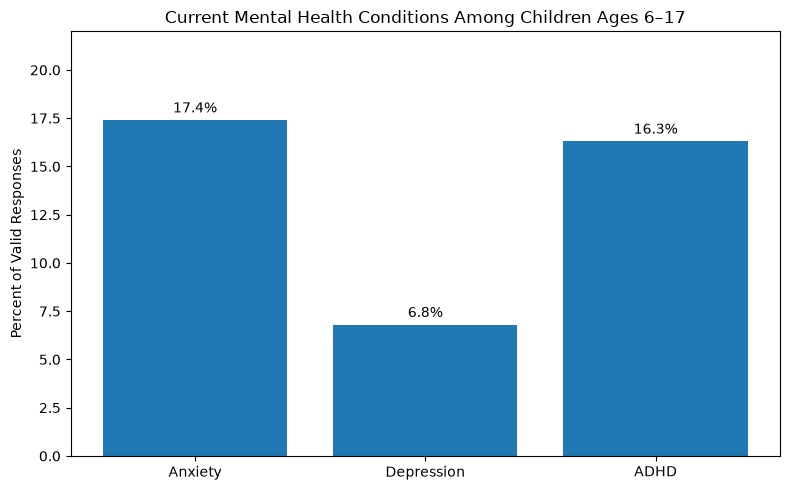

In [39]:
import matplotlib.pyplot as plt

condition_plot = pd.DataFrame({
    "Condition": ["Anxiety", "Depression", "ADHD"],
    "Percent": [17.4, 6.8, 16.3]
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    condition_plot["Condition"],
    condition_plot["Percent"]
)

plt.title("Current Mental Health Conditions Among Children Ages 6–17")
plt.ylabel("Percent of Valid Responses")
plt.xlabel("")

for bar, value in zip(bars, condition_plot["Percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, 22)
plt.tight_layout()
plt.show()

### Three Conditions Finding

Among the three conditions included in the target population, current anxiety was the most common at 17.4%, followed closely by ADHD at 16.3%. Current depression was reported for 6.8% of valid responses.

These unweighted percentages describe the cleaned NSCH sample and should not be interpreted as national prevalence estimates.

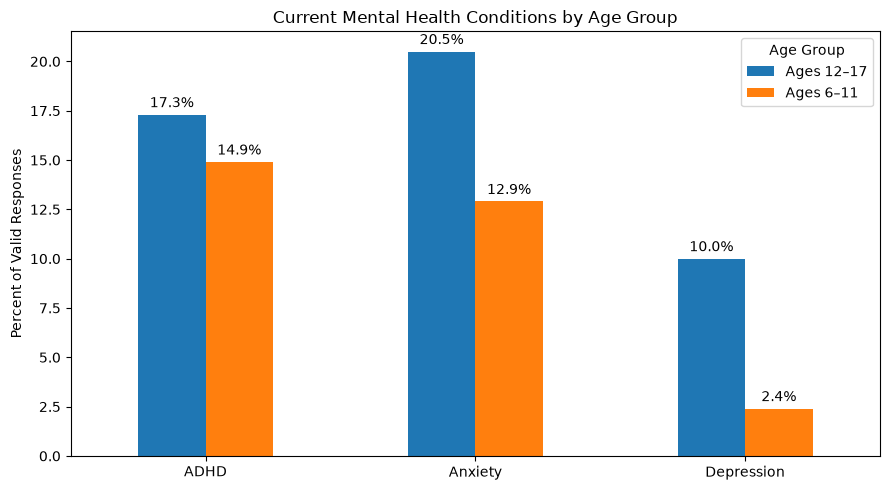

In [43]:
age_condition_plot = pd.DataFrame({
    "Condition": [
        "Anxiety", "Depression", "ADHD",
        "Anxiety", "Depression", "ADHD"
    ],
    "Age Group": [
        "Ages 6–11", "Ages 6–11", "Ages 6–11",
        "Ages 12–17", "Ages 12–17", "Ages 12–17"
    ],
    "Percent": [
        12.9, 2.4, 14.9,
        20.5, 10.0, 17.3
    ]
})

pivot_age = age_condition_plot.pivot(
    index="Condition",
    columns="Age Group",
    values="Percent"
)

ax = pivot_age.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Current Mental Health Conditions by Age Group")
plt.ylabel("Percent of Valid Responses")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Age Group")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### Finding: Mental Health Conditions by Age Group

The condition profile changes substantially with age.

Among children ages 6–11, ADHD was the most common of the three conditions at 14.9%, compared with 12.9% for anxiety and 2.4% for depression.

Among adolescents ages 12–17, anxiety increased to 20.5% and became the most common condition. Depression also increased substantially to 10.0%, while ADHD increased more modestly to 17.3%.

This suggests that age is particularly important for understanding the distribution of anxiety and depression, even though later analyses found age to have a relatively weak association with unmet care.

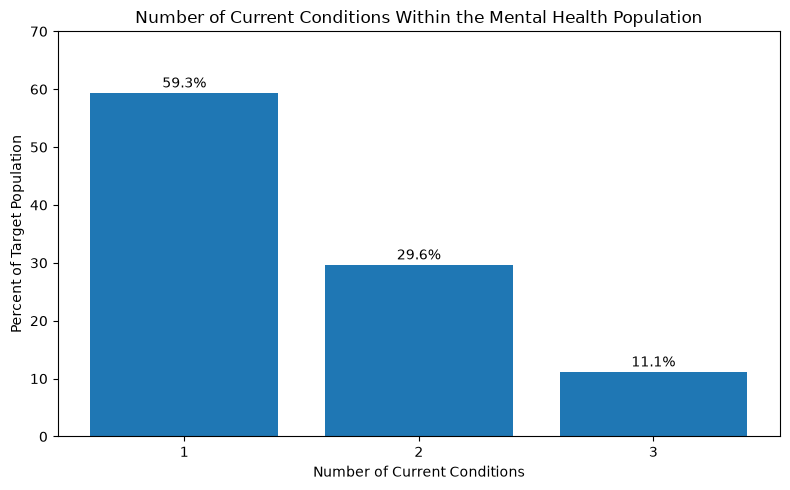

In [41]:
comorbidity_plot = (
    target_population["current_condition_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

comorbidity_plot.columns = [
    "Number of Conditions",
    "Children"
]

comorbidity_plot["Percent"] = (
    comorbidity_plot["Children"]
    / comorbidity_plot["Children"].sum()
    * 100
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    comorbidity_plot["Number of Conditions"].astype(str),
    comorbidity_plot["Percent"]
)

plt.title("Number of Current Conditions Within the Mental Health Population")
plt.xlabel("Number of Current Conditions")
plt.ylabel("Percent of Target Population")

for bar, value in zip(
    bars,
    comorbidity_plot["Percent"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, 70)
plt.tight_layout()
plt.show()

### Comorbidity Finding

Comorbidity was common among children with current anxiety, depression, or ADHD.

Approximately 59.3% had one of the three conditions, 29.6% had two, and 11.1% had all three.

Together, 40.7% of the target mental health population had two or more current conditions, showing that a substantial share of children in this population experience overlapping mental health needs.

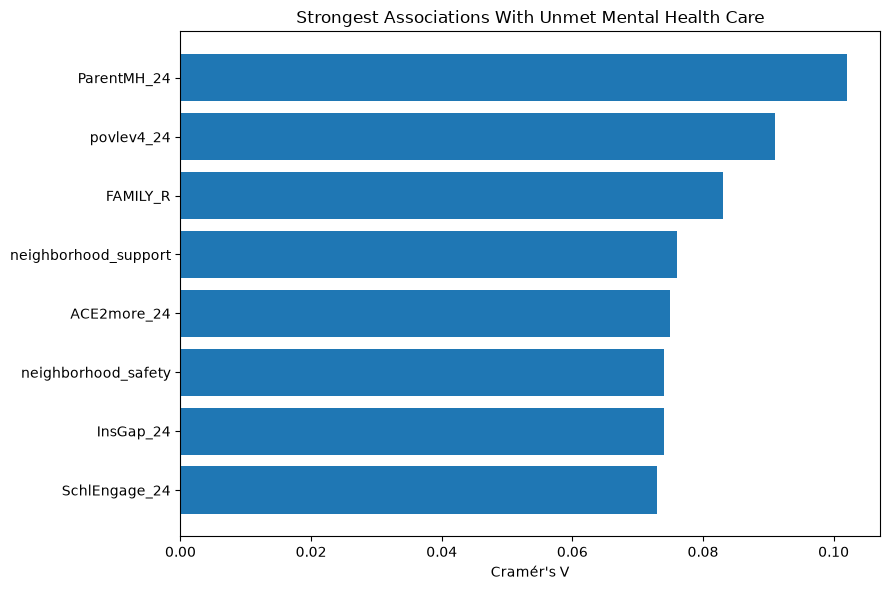

In [42]:
top_associations = (
    nsch_chi_square
    if "nsch_chi_square" in globals()
    else chi_square_df
)

top_associations = (
    top_associations
    .sort_values("Cramer's V", ascending=False)
    .head(8)
    .sort_values("Cramer's V")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_associations["Factor"],
    top_associations["Cramer's V"]
)

plt.title("Strongest Associations With Unmet Mental Health Care")
plt.xlabel("Cramér's V")
plt.ylabel("")

plt.tight_layout()
plt.show()

### Bivariate Finding

The strongest bivariate associations with unmet mental health care were concentrated in family, socioeconomic, insurance, school, and neighborhood conditions.

Parent mental health showed the largest Cramér's V, followed by poverty level, family factors, neighborhood support, ACE exposure, insurance gaps, neighborhood safety, and school engagement.

Although these relationships were statistically significant, the effect sizes were generally small. This suggests that unmet mental health care is associated with multiple overlapping conditions rather than one dominant risk factor.

In [46]:
import nbformat as nbf
from pathlib import Path

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

master_path = Path(
    "../Final_Data_Analysis/07_full_project_analysis.ipynb"
)

nb = nbf.read(master_path, as_version=4)

# ---------------------------------------------------------
# New NSCH EDA cells
# ---------------------------------------------------------

new_cells = []

new_cells.append(nbf.v4.new_markdown_cell("""
## 2.9 Exploratory Data Analysis Visualizations

The following visualizations summarize the major distributions and relationships identified during the NSCH analysis. These plots focus on mental health prevalence, age differences, comorbidity, and factors associated with unmet mental health care.
"""))

# 1. Prevalence chart
new_cells.append(nbf.v4.new_code_cell("""
import matplotlib.pyplot as plt

condition_plot = pd.DataFrame({
    "Condition": ["Anxiety", "Depression", "ADHD"],
    "Percent": [17.4, 6.8, 16.3]
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    condition_plot["Condition"],
    condition_plot["Percent"]
)

plt.title("Current Mental Health Conditions Among Children Ages 6–17")
plt.ylabel("Percent of Valid Responses")
plt.xlabel("")

for bar, value in zip(bars, condition_plot["Percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, 22)
plt.tight_layout()
plt.show()
"""))

new_cells.append(nbf.v4.new_markdown_cell("""
### Finding: Current Condition Prevalence

Among the three conditions included in the target population, current anxiety was the most common at 17.4%, followed closely by ADHD at 16.3%. Current depression was reported for 6.8% of valid responses.

These unweighted percentages describe the cleaned NSCH sample and should not be interpreted as national prevalence estimates.
"""))

# 2. Age group chart
new_cells.append(nbf.v4.new_code_cell("""
age_condition_plot = pd.DataFrame({
    "Condition": [
        "Anxiety", "Depression", "ADHD",
        "Anxiety", "Depression", "ADHD"
    ],
    "Age Group": [
        "Ages 6–11", "Ages 6–11", "Ages 6–11",
        "Ages 12–17", "Ages 12–17", "Ages 12–17"
    ],
    "Percent": [
        12.9, 2.4, 14.9,
        20.5, 10.0, 17.3
    ]
})

pivot_age = age_condition_plot.pivot(
    index="Condition",
    columns="Age Group",
    values="Percent"
)

ax = pivot_age.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Current Mental Health Conditions by Age Group")
plt.ylabel("Percent of Valid Responses")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Age Group")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()
"""))

new_cells.append(nbf.v4.new_markdown_cell("""
### Finding: Mental Health Conditions by Age Group

Among children ages 6–11, ADHD was the most common of the three conditions at 14.9%, compared with 12.9% for anxiety and 2.4% for depression.

Among adolescents ages 12–17, anxiety increased to 20.5% and became the most common condition. Depression also increased substantially to 10.0%, while ADHD increased more modestly to 17.3%.

Age is therefore particularly important for understanding the distribution of anxiety and depression, even though later analyses found age to have a relatively weak association with unmet care.
"""))

# 3. Comorbidity chart
new_cells.append(nbf.v4.new_code_cell("""
comorbidity_plot = (
    target_population["current_condition_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

comorbidity_plot.columns = [
    "Number of Conditions",
    "Children"
]

comorbidity_plot["Percent"] = (
    comorbidity_plot["Children"]
    / comorbidity_plot["Children"].sum()
    * 100
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    comorbidity_plot["Number of Conditions"].astype(str),
    comorbidity_plot["Percent"]
)

plt.title("Number of Current Conditions Within the Mental Health Population")
plt.xlabel("Number of Current Conditions")
plt.ylabel("Percent of Target Population")

for bar, value in zip(
    bars,
    comorbidity_plot["Percent"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, 70)
plt.tight_layout()
plt.show()
"""))

new_cells.append(nbf.v4.new_markdown_cell("""
### Finding: Comorbidity

Comorbidity was common among children with current anxiety, depression, or ADHD.

Approximately 59.3% had one of the three conditions, 29.6% had two, and 11.1% had all three.

Together, 40.7% of the target mental health population had two or more current conditions.
"""))

# 4. Strongest associations chart
new_cells.append(nbf.v4.new_code_cell("""
top_associations = (
    nsch_chi_square
    .sort_values("Cramer's V", ascending=False)
    .head(8)
    .sort_values("Cramer's V")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_associations["Factor"],
    top_associations["Cramer's V"]
)

plt.title("Strongest Associations With Unmet Mental Health Care")
plt.xlabel("Cramér's V")
plt.ylabel("")

plt.tight_layout()
plt.show()
"""))

new_cells.append(nbf.v4.new_markdown_cell("""
### Finding: Strongest Associations With Unmet Care

The strongest bivariate associations with unmet mental health care were concentrated in family, socioeconomic, insurance, school, and neighborhood conditions.

Parent mental health showed the largest Cramér's V, followed by poverty level, family factors, neighborhood support, ACE exposure, insurance gaps, neighborhood safety, and school engagement.

Although these relationships were statistically significant, effect sizes were generally small, suggesting that unmet mental health care is associated with multiple overlapping conditions rather than one dominant risk factor.
"""))

# ---------------------------------------------------------
# Find where ACS section begins
# ---------------------------------------------------------

insert_index = None

for i, cell in enumerate(nb.cells):
    if (
        cell.cell_type == "markdown"
        and "# 3. American Community Survey" in cell.source
    ):
        insert_index = i
        break

if insert_index is None:
    raise ValueError("Could not find ACS section in master notebook.")

# ---------------------------------------------------------
# Insert NSCH EDA right before ACS
# ---------------------------------------------------------

nb.cells[insert_index:insert_index] = new_cells

# ---------------------------------------------------------
# Save updated master notebook
# ---------------------------------------------------------

nbf.write(nb, master_path)

print("Updated:", master_path.resolve())
print("Inserted", len(new_cells), "NSCH EDA cells.")

ValueError: Could not find ACS section in master notebook.

In [47]:
# FINAL_NOTEBOOK_TRANSFER_HELPER

import nbformat
from pathlib import Path
from copy import deepcopy

# --------------------------------------------------
# Paths
# --------------------------------------------------

analysis_dir = Path("../Data_Analysis_Notebooks")
final_path = Path("../Final_Data_Analysis/07_full_project_analysis.ipynb")

source_files = [
    analysis_dir / "01_nsch_data_analysis.ipynb",
    analysis_dir / "02_acs_data_analysis.ipynb",
    analysis_dir / "03_nces_fiscal_data_analysis.ipynb",
    analysis_dir / "04_nces_nonfiscal_data_analysis.ipynb",
]

# --------------------------------------------------
# Build final notebook from completed source notebooks
# --------------------------------------------------

combined_cells = []

for source_path in source_files:

    with open(source_path, "r", encoding="utf-8") as f:
        source_nb = nbformat.read(f, as_version=4)

    for cell in source_nb.cells:

        # Do not copy transfer-helper cells into the final notebook
        if (
            cell.cell_type == "code"
            and "FINAL_NOTEBOOK_TRANSFER_HELPER" in cell.source
        ):
            continue

        combined_cells.append(deepcopy(cell))

# --------------------------------------------------
# Create fresh final combined notebook
# --------------------------------------------------

final_nb = nbformat.v4.new_notebook()
final_nb.cells = combined_cells

with open(final_path, "w", encoding="utf-8") as f:
    nbformat.write(final_nb, f)

print("FINAL NOTEBOOK UPDATED SUCCESSFULLY")
print("Total cells copied:", len(combined_cells))
print("Saved to:", final_path.resolve())
print()
print("Included:")
print("✓ NSCH")
print("✓ ACS")
print("✓ NCES Fiscal")
print("✓ NCES Nonfiscal")

FINAL NOTEBOOK UPDATED SUCCESSFULLY
Total cells copied: 172
Saved to: C:\Users\akila\pediatric-mental-health-analysis\notebooks\Final_Data_Analysis\07_full_project_analysis.ipynb

Included:
✓ NSCH
✓ ACS
✓ NCES Fiscal
✓ NCES Nonfiscal
